In [ ]:
# pip install scikit-learn==0.23.2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/cleveland.csv', header = None)

df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol',
              'fbs', 'restecg', 'thalach', 'exang', 
              'oldpeak', 'slope', 'ca', 'thal', 'target']

In [ ]:
################################## data preprocessing ####################################################

### Mapeia as classes transformando o problema em binário
df['target'] = df.target.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})

### Verifica se há valores nulos
print(df.isnull().sum())

### Substitui os valores nulos pela média ##
df.fillna(df.mean(), inplace=True)

############################################

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

## Separa os dados em treinamento e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Normaliza os dados ###############################
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

######################################################

### Aplica PCA #######################################
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # Mantém 95% da variância
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

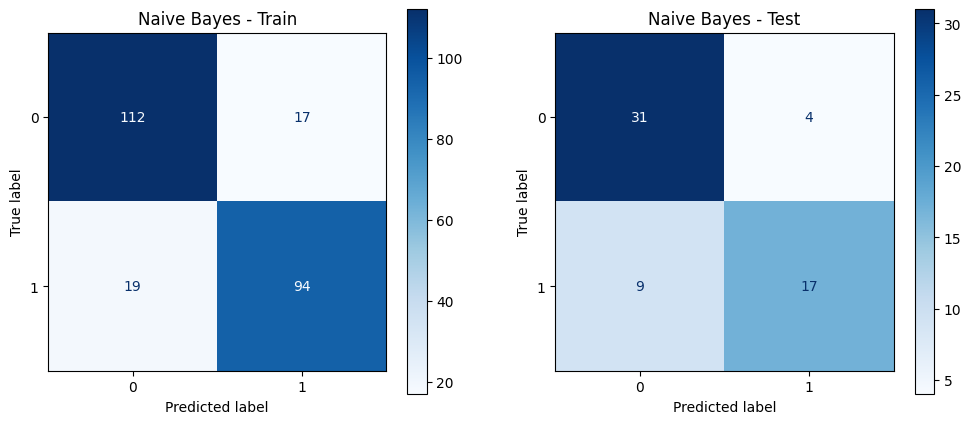

Accuracy for training set = 0.8512
Accuracy for test set = 0.7869


In [8]:
##############################   Naive Bayes  ##############################
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Treinamento do modelo
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_test = classifier.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred_test)

# Previsões no conjunto de treinamento
y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)

# Plotando as matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Cria subplots lado a lado

# Matriz de confusão do conjunto de treino
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Naive Bayes - Train')

# Matriz de confusão do conjunto de teste
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Naive Bayes - Test')

plt.show()

# Acurácia
accuracy_train = (cm_train[0][0] + cm_train[1][1]) / len(y_train)
accuracy_test = (cm_test[0][0] + cm_test[1][1]) / len(y_test)

print(f'Accuracy for training set = {accuracy_train:.4f}')
print(f'Accuracy for test set = {accuracy_test:.4f}')


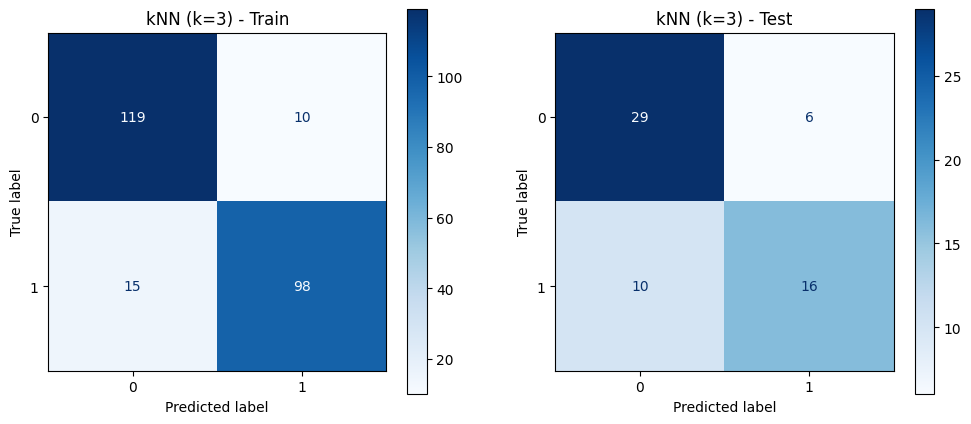

Accuracy for training set (k=3) = 0.8967
Accuracy for test set (k=3) = 0.7377
--------------------------------------------------


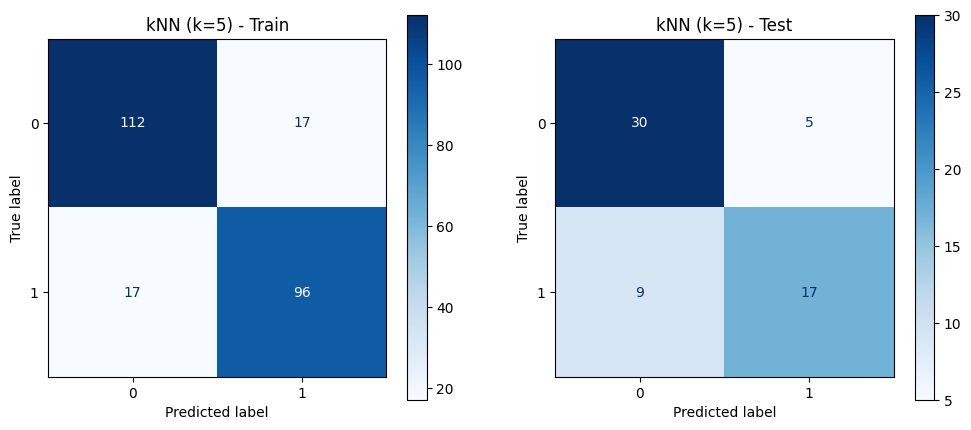

Accuracy for training set (k=5) = 0.8595
Accuracy for test set (k=5) = 0.7705
--------------------------------------------------


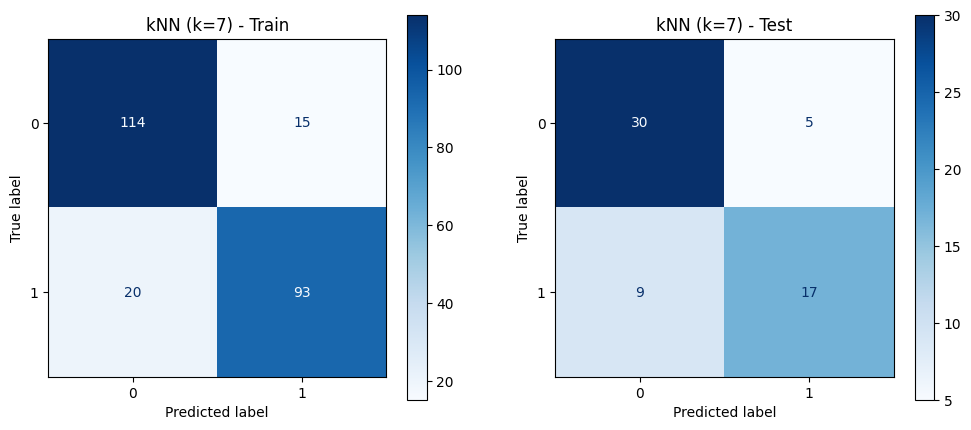

Accuracy for training set (k=7) = 0.8554
Accuracy for test set (k=7) = 0.7705
--------------------------------------------------


In [9]:
##############################   KNN  ##############################
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Função para treinar e testar o modelo kNN e gerar as matrizes de confusão lado a lado
def knn_model(k, X_train, y_train, X_test, y_test):
    # Treinamento do modelo
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    
    # Previsões no conjunto de teste
    y_pred_test = knn.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_test)
    
    # Previsões no conjunto de treinamento
    y_pred_train = knn.predict(X_train)
    cm_train = confusion_matrix(y_train, y_pred_train)
    
    # Plotando as matrizes de confusão lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Cria subplots lado a lado
    
    # Matriz de confusão do conjunto de treino
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title(f'kNN (k={k}) - Train')
    
    # Matriz de confusão do conjunto de teste
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap=plt.cm.Blues)
    axes[1].set_title(f'kNN (k={k}) - Test')
    
    plt.show()
    
    # Acurácia
    accuracy_train = (cm_train[0][0] + cm_train[1][1]) / len(y_train)
    accuracy_test = (cm_test[0][0] + cm_test[1][1]) / len(y_test)
    
    print(f'Accuracy for training set (k={k}) = {accuracy_train:.4f}')
    print(f'Accuracy for test set (k={k}) = {accuracy_test:.4f}')
    print('-' * 50)

# Rodar o modelo para k = 3, 5, 7
for k in [3, 5, 7]:
    knn_model(k, X_train, y_train, X_test, y_test)


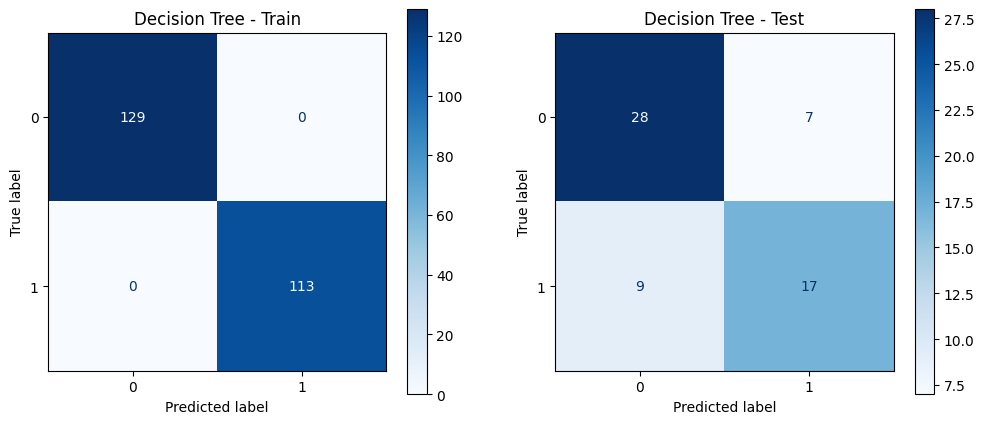

Accuracy for training set = 1.0000
Accuracy for test set = 0.7377
--------------------------------------------------


In [10]:
############################## Decision Tree ##############################
import matplotlib.pyplot as plt
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ignorar warnings futuros do SciPy
warnings.simplefilter(action='ignore', category=FutureWarning)

# Função para treinar e testar o modelo de Árvore de Decisão e gerar as matrizes de confusão
def decision_tree_model(X_train, y_train, X_test, y_test):
    # Treinamento do modelo
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    
    # Previsões no conjunto de teste
    y_pred_test = tree.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_test)
    
    # Previsões no conjunto de treinamento
    y_pred_train = tree.predict(X_train)
    cm_train = confusion_matrix(y_train, y_pred_train)
    
    # Plotando as matrizes de confusão lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Cria subplots lado a lado
    
    # Matriz de confusão do conjunto de treino
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title(f'Decision Tree - Train')
    
    # Matriz de confusão do conjunto de teste
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap=plt.cm.Blues)
    axes[1].set_title(f'Decision Tree - Test')
    
    plt.show()
    
    # Acurácia
    accuracy_train = (cm_train[0][0] + cm_train[1][1]) / len(y_train)
    accuracy_test = (cm_test[0][0] + cm_test[1][1]) / len(y_test)
    
    print(f'Accuracy for training set = {accuracy_train:.4f}')
    print(f'Accuracy for test set = {accuracy_test:.4f}')
    print('-' * 50)

# Rodar o modelo de Árvore de Decisão
decision_tree_model(X_train, y_train, X_test, y_test)


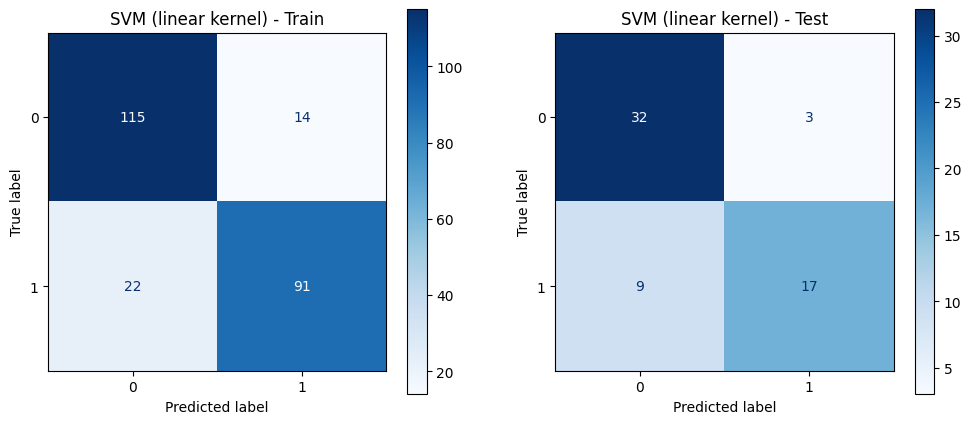

Accuracy for training set (SVM linear) = 0.8512
Accuracy for test set (SVM linear) = 0.8033
--------------------------------------------------


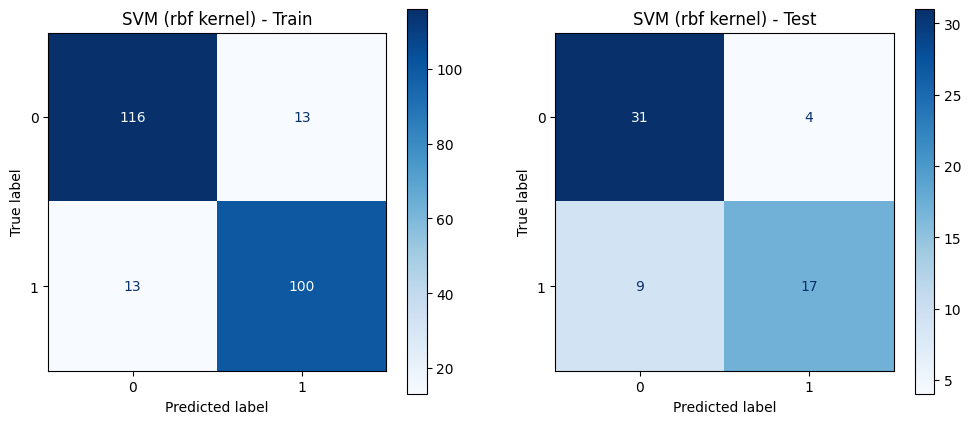

Accuracy for training set (SVM rbf) = 0.8926
Accuracy for test set (SVM rbf) = 0.7869
--------------------------------------------------


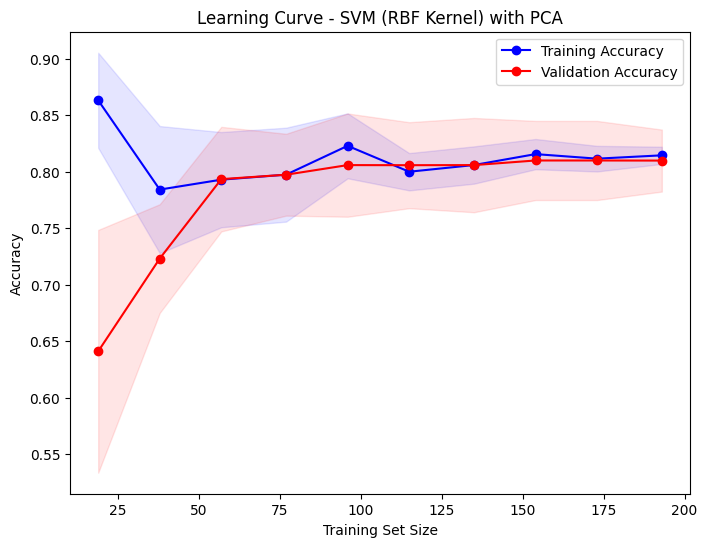

In [12]:
############################## SVM - Support Vector Machines ##############################
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

# Ignorar warnings futuros
warnings.simplefilter(action='ignore', category=FutureWarning)

# Função para treinar e testar o modelo SVM e gerar as matrizes de confusão
def svm_model(kernel, X_train, y_train, X_test, y_test):
    # Treinamento do modelo
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    
    # Previsões no conjunto de teste
    y_pred_test = svm.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_test)
    
    # Previsões no conjunto de treinamento
    y_pred_train = svm.predict(X_train)
    cm_train = confusion_matrix(y_train, y_pred_train)
    
    # Plotando as matrizes de confusão lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Matriz de confusão do conjunto de treino
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title(f'SVM ({kernel} kernel) - Train')
    
    # Matriz de confusão do conjunto de teste
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap=plt.cm.Blues)
    axes[1].set_title(f'SVM ({kernel} kernel) - Test')
    
    plt.show()
    
    # Acurácia
    accuracy_train = (cm_train[0][0] + cm_train[1][1]) / len(y_train)
    accuracy_test = (cm_test[0][0] + cm_test[1][1]) / len(y_test)
    
    print(f'Accuracy for training set (SVM {kernel}) = {accuracy_train:.4f}')
    print(f'Accuracy for test set (SVM {kernel}) = {accuracy_test:.4f}')
    print('-' * 50)

# Rodar o modelo SVM com kernel linear e RBF
for kernel in ['linear', 'rbf']:
    svm_model(kernel, X_train, y_train, X_test, y_test)


# --------------------- PCA e Curva de Aprendizado --------------------- #

# Reduzindo a matriz de entrada para os dois primeiros componentes principais (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Treinando o SVM com kernel RBF usando apenas os dois primeiros scores do PCA
svm_rbf_pca = SVC(kernel='rbf', random_state=42)
train_sizes, train_scores, test_scores = learning_curve(
    svm_rbf_pca, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Cálculo da média e desvio padrão das curvas de aprendizado
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotando a curva de aprendizado
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="red", label="Validation Accuracy")

# Adicionando a sombra do desvio padrão
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - SVM (RBF Kernel) with PCA")
plt.legend()
plt.show()


<h3>Resultados de Acurácia dos Algoritmos</h3>
    <table>
        <tr>
            <th>Algoritmo</th>
            <th>Acurácia (Treinamento)</th>
            <th>Acurácia (Teste)</th>
        </tr>
        <tr>
            <td>Naive Bayes</td>
            <td>0.85</td>
            <td>0.78</td>
        </tr>
        <tr>
            <td>kNN (k=3)</td>
            <td>0.89</td>
            <td>0.73</td>
        </tr>
        <tr>
            <td>kNN (k=5)</td>
            <td>0.85</td>
            <td>0.77</td>
        </tr>
        <tr>
            <td>kNN (k=7)</td>
            <td>0.85</td>
            <td>0.77</td>
        </tr>
        <tr>
            <td>Decision Tree</td>
            <td>1.00</td>
            <td>0.73</td>
        </tr>
        <tr>
            <td>SVM (linear)</td>
            <td>0.85</td>
            <td>0.80</td>
        </tr>
        <tr>
            <td>SVM (RBF)</td>
            <td>0.89</td>
            <td>0.78</td>
        </tr>
    </table>

<b>Neste problema, a acurácia é uma boa métrica para comparar cada algoritmo? Se não,
qual medida poderia ser utilizada?</b>
<br><br>Embora a acurácia seja amplamente utilizada, ela pode não ser uma boa métrica quando há desbalanceamento nas classes. 
Em problemas desbalanceados, um modelo pode simplesmente prever a classe majoritária e ainda obter uma boa acurácia, 
mas não estará fazendo boas previsões para a classe minoritária.
Para classificar o modelo, é mais confiável usar F1-Score quando o conjunto de dados é desbalanceado, pois ele leva em conta tanto a precisão quanto o recall.

Repita os resultados de cada algoritmo, porém, utilizando validação cruzada (com k =
10). Discuta os resultados comparando-os com os resultados utilizando a partição 80-
20.

In [67]:
from sklearn.model_selection import cross_val_score

# Lista de algoritmos
models = {
    'Naive Bayes': GaussianNB(),
    'kNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'kNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier()
}

# Resultado da validação cruzada
cv_results = {}
for name, model in models.items():
    cv_results[name] = cross_val_score(model, X, y, cv=10, scoring='accuracy')

# Exibindo os resultados da validação cruzada
for name, result in cv_results.items():
    print(f'{name}: Acurácia Média = {np.mean(result):.4f}, Desvio Padrão = {np.std(result):.4f}')


Naive Bayes: Acurácia Média = 0.8480, Desvio Padrão = 0.0637
kNN (k=3): Acurácia Média = 0.6337, Desvio Padrão = 0.0931
kNN (k=5): Acurácia Média = 0.6568, Desvio Padrão = 0.0975
kNN (k=7): Acurácia Média = 0.6700, Desvio Padrão = 0.0891
Decision Tree: Acurácia Média = 0.7580, Desvio Padrão = 0.1024


Os resultados de validação cruzada com k=10 mostraram uma acurácia mais baixa e variável em comparação com a partição 80-20. O Naive Bayes manteve uma boa consistência, enquanto o kNN teve desempenho inferior, sugerindo overfitting na partição 80-20. A Decision Tree teve uma acurácia mais baixa na validação cruzada, indicando tendência a overfitting. Isso demonstra que a validação cruzada oferece uma avaliação mais realista e estável do desempenho dos algoritmos.